In [6]:
import json
import pickle
import numpy as np
import pandas as pd
import rdkit
from rdkit.Chem import AllChem
import py3Dmol
from joblib import Parallel, delayed
from ringer.utils import chem, internal_coords
import matplotlib.pyplot as plt

In [7]:
def visualize_conformer(mol, title, id=0):
    viewer = py3Dmol.view(width=400, height=400)
    if mol.GetNumConformers() > 0:
        mol_block = rdkit.Chem.MolToMolBlock(mol, confId=id)
        viewer.addModel(mol_block, "mol")
        viewer.setStyle({"stick": {"color": "spectrum"}})
        viewer.zoomTo()
        viewer.setBackgroundColor("white")
        print(f"{title} - Conformer {id}")
        return viewer
    else:
        print(f"{title} has no conformers")
        return None

In [8]:
with open("sample/reconstructed_mols/F.Mec.q.Y.pickle", "rb") as source:
    s_o_mol = pickle.load(source)
s_o_mol.GetNumConformers()

2756

In [9]:
with open("sample/reconstructed_mols_no_opt/F.Mec.q.Y.pickle", "rb") as source:
    s_no_o_mol = pickle.load(source)
s_no_o_mol.GetNumConformers()

2756

In [10]:
def compare_ring_bond_lengths_to_training_means(
    mol,
    conf_id=0,
    means_path="assets/models/conditional/training_mean_distances.json",
):
    with open(means_path, "r") as source:
        mean_distances = json.load(source)

    macrocycle_idxs = chem.get_macrocycle_idxs(mol, n_to_c=True)
    if macrocycle_idxs is None:
        raise ValueError("No macrocycle indices found for molecule")

    bond_idxs = internal_coords.get_macrocycle_bond_idxs(macrocycle_idxs)
    conf = mol.GetConformer(int(conf_id))

    atom_labels = ["N", "Calpha", "CO"]
    rows = []
    for ring_pos, (idx1, idx2) in enumerate(bond_idxs):
        atom_label = atom_labels[ring_pos % 3]
        expected = float(mean_distances[atom_label])
        actual = float(AllChem.GetBondLength(conf, int(idx1), int(idx2)))
        delta = actual - expected
        rows.append(
            {
                "ring_bond_pos": ring_pos,
                "atom_i": int(idx1),
                "atom_j": int(idx2),
                "first_atom_label": atom_label,
                "expected_length": expected,
                "actual_length": actual,
                "delta": delta,
            }
        )

    df = pd.DataFrame(rows)
    df["abs_delta"] = df["delta"].abs()
    df["rel_abs_delta_pct"] = 100.0 * df["abs_delta"] / df["expected_length"]

    likely_broken = df.loc[df["abs_delta"].idxmax()].copy()
    return df, likely_broken, macrocycle_idxs, mean_distances

In [11]:
demo_mol = s_no_o_mol
means_path = "assets/models/conditional/training_mean_distances.json"

with open(means_path, "r") as source:
    mean_distances_demo = json.load(source)

macrocycle_idxs_raw = chem.get_macrocycle_idxs(demo_mol, n_to_c=False)
macrocycle_idxs_n2c = chem.get_macrocycle_idxs(demo_mol, n_to_c=True)
bond_idxs = internal_coords.get_macrocycle_bond_idxs(macrocycle_idxs_n2c)

print("INPUT 1 (raw ring order, n_to_c=False):")
print(macrocycle_idxs_raw)
print("\nOUTPUT 1 (canonical ring order, n_to_c=True, starts at N):")
print(macrocycle_idxs_n2c)

print("\nINPUT 2: get_macrocycle_bond_idxs(macrocycle_idxs_n2c)")
print("Input length:", len(macrocycle_idxs_n2c))
print("Input list:", macrocycle_idxs_n2c)

print("\nOUTPUT 2: wrapped adjacent bond pairs")
print(bond_idxs)
print("Last bond closes ring:", bond_idxs[-1], "==", (macrocycle_idxs_n2c[-1], macrocycle_idxs_n2c[0]))

atom_labels_cycle = ["N", "Calpha", "CO"]
rows = []
for ring_pos, (idx1, idx2) in enumerate(bond_idxs):
    label = atom_labels_cycle[ring_pos % 3]
    rows.append(
        {
            "ring_bond_pos": ring_pos,
            "atom_i(first)": int(idx1),
            "atom_j(second)": int(idx2),
            "assigned_label_from_first_atom": label,
            "mean_length_from_json": float(mean_distances_demo[label]),
            "actual_length": float(AllChem.GetBondLength(demo_mol.GetConformer(0), int(idx1), int(idx2))),
        }
    )

mapping_df = pd.DataFrame(rows)
print("\nFinal mapping used in compare_ring_bond_lengths_to_training_means:")
display(mapping_df)

INPUT 1 (raw ring order, n_to_c=False):
[1, 36, 34, 33, 27, 25, 24, 15, 13, 12, 4, 2]

OUTPUT 1 (canonical ring order, n_to_c=True, starts at N):
[33, 27, 25, 24, 15, 13, 12, 4, 2, 1, 36, 34]

INPUT 2: get_macrocycle_bond_idxs(macrocycle_idxs_n2c)
Input length: 12
Input list: [33, 27, 25, 24, 15, 13, 12, 4, 2, 1, 36, 34]

OUTPUT 2: wrapped adjacent bond pairs
[[33, 27], [27, 25], [25, 24], [24, 15], [15, 13], [13, 12], [12, 4], [4, 2], [2, 1], [1, 36], [36, 34], [34, 33]]
Last bond closes ring: [34, 33] == (34, 33)

Final mapping used in compare_ring_bond_lengths_to_training_means:


,ring_bond_pos,atom_i(first),atom_j(second),assigned_label_from_first_atom,mean_length_from_json,actual_length
0,0,33,27,N,1.455443,1.457400
1,1,27,25,Calpha,1.535209,1.536800
2,2,25,24,CO,1.338638,1.341300
3,3,24,15,N,1.455443,1.457600
4,4,15,13,Calpha,1.535209,1.536700
5,5,13,12,CO,1.338638,1.341300
6,6,12,4,N,1.455443,1.457400
7,7,4,2,Calpha,1.535209,1.536700
8,8,2,1,CO,1.338638,1.574369
9,9,1,36,N,1.455443,1.457100


In [12]:
def _compare_ring_bonds_single_conf(conf_id, bond_idxs, positions, expected_per_pos, atom_label_per_pos):
    rows = []
    for ring_pos, (idx1, idx2) in enumerate(bond_idxs):
        expected = expected_per_pos[ring_pos]
        actual = float(np.linalg.norm(positions[idx1] - positions[idx2]))
        delta = actual - expected
        rows.append(
            {
                "conf_id": int(conf_id),
                "ring_bond_pos": ring_pos,
                "atom_i": int(idx1),
                "atom_j": int(idx2),
                "first_atom_label": atom_label_per_pos[ring_pos],
                "expected_length": expected,
                "actual_length": actual,
                "delta": delta,
            }
        )
    return rows


def compare_ring_bond_lengths_all_conformers(
    mol,
    means_path="assets/models/conditional/training_mean_distances.json",
    n_jobs=-1,
):
    with open(means_path, "r") as source:
        mean_distances = json.load(source)

    macrocycle_idxs = chem.get_macrocycle_idxs(mol, n_to_c=True)
    if macrocycle_idxs is None:
        raise ValueError("No macrocycle indices found for molecule")

    bond_idxs = internal_coords.get_macrocycle_bond_idxs(macrocycle_idxs)
    if mol.GetNumConformers() == 0:
        raise ValueError("Molecule has no conformers")

    atom_labels = ["N", "Calpha", "CO"]
    atom_label_per_pos = [atom_labels[i % 3] for i in range(len(bond_idxs))]
    expected_per_pos = [float(mean_distances[lbl]) for lbl in atom_label_per_pos]

    conf_positions = [
        (conf.GetId(), np.asarray(conf.GetPositions())) for conf in mol.GetConformers()
    ]

    results = Parallel(n_jobs=n_jobs)(
        delayed(_compare_ring_bonds_single_conf)(
            conf_id, bond_idxs, positions, expected_per_pos, atom_label_per_pos
        )
        for conf_id, positions in conf_positions
    )

    df = pd.DataFrame([row for conf_rows in results for row in conf_rows])
    df["abs_delta"] = df["delta"].abs()
    df["rel_abs_delta_pct"] = 100.0 * df["abs_delta"] / df["expected_length"]

    worst_per_conf = (
        df.loc[df.groupby("conf_id")["abs_delta"].idxmax()]
        .sort_values("abs_delta", ascending=False)
        .reset_index(drop=True)
    )

    return df, worst_per_conf, macrocycle_idxs, mean_distances

In [ ]:
all_bonds_df, worst_per_conf, macrocycle_idxs, _ = compare_ring_bond_lengths_all_conformers(s_no_o_mol)
worst_per_conf

In [ ]:
all_bonds_df, worst_per_conf, macrocycle_idxs, _ = compare_ring_bond_lengths_all_conformers(s_o_mol)

In [ ]:
worst_per_conf

In [ ]:
target_mol = s_o_mol
target_conf_id = 0

bond_df, likely_broken_row, macrocycle_idxs, training_mean_distances = compare_ring_bond_lengths_to_training_means(
    target_mol,
    conf_id=target_conf_id,
)

print(f"Macrocycle atom count: {len(macrocycle_idxs)}")
print(f"Conformer analyzed: {target_conf_id}")
display(bond_df)

print("Likely broken bond during best_dist init (max |delta|):")
display(pd.DataFrame([likely_broken_row]))


In [ ]:
def visualize_conformer_with_broken_bond(
    mol,
    title,
    conf_id=0,
    broken_bond=None,
    label_text=None,
    width=700,
    height=550,
):
    viewer = py3Dmol.view(width=width, height=height)
    if mol.GetNumConformers() == 0:
        print(f"{title} has no conformers")
        return None

    mol_block = rdkit.Chem.MolToMolBlock(mol, confId=int(conf_id))
    viewer.addModel(mol_block, "mol")
    viewer.setStyle({}, {"stick": {"color": "lightgray", "radius": 0.12}})

    if broken_bond is not None:
        idx1, idx2 = map(int, broken_bond)
        viewer.setStyle(
            {"index": [idx1, idx2]},
            {"stick": {"color": "red", "radius": 0.26}, "sphere": {"color": "red", "radius": 0.36}},
        )

        conf = mol.GetConformer(int(conf_id))
        p1 = conf.GetAtomPosition(idx1)
        p2 = conf.GetAtomPosition(idx2)
        start = {"x": float(p1.x), "y": float(p1.y), "z": float(p1.z)}
        end = {"x": float(p2.x), "y": float(p2.y), "z": float(p2.z)}
        mid = {
            "x": 0.5 * (start["x"] + end["x"]),
            "y": 0.5 * (start["y"] + end["y"]),
            "z": 0.5 * (start["z"] + end["z"]),
        }

        viewer.addLine({"start": start, "end": end, "color": "red", "linewidth": 6})
        viewer.addLabel(
            label_text if label_text is not None else f"Likely broken init bond: {idx1}-{idx2}",
            {
                "position": mid,
                "fontSize": 13,
                "backgroundColor": "black",
                "fontColor": "white",
                "inFront": True,
            },
        )
        viewer.zoomTo({"index": [idx1, idx2]})

    viewer.setBackgroundColor("white")
    print(f"{title} - Conformer {conf_id}")
    return viewer


broken_bond = (int(likely_broken_row["atom_i"]), int(likely_broken_row["atom_j"]))
label = (
    f"Likely broken init bond {broken_bond[0]}-{broken_bond[1]} | "
    f"actual={likely_broken_row['actual_length']:.3f} A, "
    f"expected={likely_broken_row['expected_length']:.3f} A, "
    f"delta={likely_broken_row['delta']:+.3f} A"
)

viewer_broken = visualize_conformer_with_broken_bond(
    target_mol,
    title="s_no_o_mol (likely broken bond highlighted)",
    conf_id=target_conf_id,
    broken_bond=broken_bond,
    label_text=label,
)
if viewer_broken:
    viewer_broken.show()


In [52]:
viewer2 = visualize_conformer(s_no_o_mol, "s_no_o_mol", id=1475)
if viewer2:
    viewer2.show()

s_no_o_mol - Conformer 1475


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [53]:
viewer1 = visualize_conformer(s_o_mol, "s_o_mol", id=1475)
if viewer1:
    viewer1.show()

s_o_mol - Conformer 1475


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [21]:
def detect_steric_clashes(
    mol,
    conf_id=0,
    scale=0.75,
    tol=0.0,
    heavy_only=True,
    min_topological_distance=3,
):
    """Detect steric clashes in one conformer using vdW overlap criterion.

    A pair (i,j) is flagged as a clash when:
        distance(i,j) < scale * (Rvdw_i + Rvdw_j) - tol

    Args:
        mol: RDKit molecule with conformers.
        conf_id: Conformer ID to analyze.
        scale: Overlap scale on vdW sum; stricter when larger.
        tol: Absolute tolerance in Angstrom subtracted from threshold.
        heavy_only: If True, ignore hydrogens.
        min_topological_distance: Only check atom pairs with shortest path >= this value
            (default=3 excludes 1-2 and 1-3 pairs).

    Returns:
        clashes_df: DataFrame of clash pairs sorted by overlap descending.
        summary: Dict with counts and settings.
    """
    if mol.GetNumConformers() == 0:
        raise ValueError("Molecule has no conformers")
    if conf_id < 0 or conf_id >= mol.GetNumConformers():
        raise ValueError(f"conf_id={conf_id} out of range for {mol.GetNumConformers()} conformers")

    conf = mol.GetConformer(int(conf_id))
    positions = np.asarray(conf.GetPositions())
    topological_dist = rdkit.Chem.GetDistanceMatrix(mol)
    pt = rdkit.Chem.GetPeriodicTable()

    atom_indices = []
    for atom in mol.GetAtoms():
        idx = atom.GetIdx()
        if heavy_only and atom.GetAtomicNum() == 1:
            continue
        atom_indices.append(idx)

    rows = []
    num_pairs_checked = 0
    for ii, i in enumerate(atom_indices):
        atom_i = mol.GetAtomWithIdx(int(i))
        zi = atom_i.GetAtomicNum()
        ri = float(pt.GetRvdw(int(zi)))
        type_i = f"{atom_i.GetSymbol()}(Z={zi},hyb={str(atom_i.GetHybridization())})"

        for j in atom_indices[ii + 1:]:
            topod = float(topological_dist[i, j])
            if topod < min_topological_distance:
                continue

            atom_j = mol.GetAtomWithIdx(int(j))
            zj = atom_j.GetAtomicNum()
            rj = float(pt.GetRvdw(int(zj)))
            type_j = f"{atom_j.GetSymbol()}(Z={zj},hyb={str(atom_j.GetHybridization())})"

            bond = mol.GetBondBetweenAtoms(int(i), int(j))
            bond_type = str(bond.GetBondType()) if bond is not None else "nonbonded"
            relation = f"1-{int(topod) + 1}"

            d = float(np.linalg.norm(positions[i] - positions[j]))
            threshold = float(scale * (ri + rj) - tol)
            num_pairs_checked += 1

            if d < threshold:
                rows.append(
                    {
                        "conf_id": int(conf_id),
                        "atom_i": int(i),
                        "atom_j": int(j),
                        "symbol_i": atom_i.GetSymbol(),
                        "symbol_j": atom_j.GetSymbol(),
                        "atom_type_i": type_i,
                        "atom_type_j": type_j,
                        "bond_type": bond_type,
                        "relation": relation,
                        "topological_distance": topod,
                        "distance": d,
                        "vdw_i": ri,
                        "vdw_j": rj,
                        "threshold": threshold,
                        "overlap": float(threshold - d),
                    }
                )

    columns = [
        "conf_id",
        "atom_i",
        "atom_j",
        "symbol_i",
        "symbol_j",
        "atom_type_i",
        "atom_type_j",
        "bond_type",
        "relation",
        "topological_distance",
        "distance",
        "vdw_i",
        "vdw_j",
        "threshold",
        "overlap",
    ]
    clashes_df = pd.DataFrame(rows, columns=columns)
    if len(clashes_df) > 0:
        clashes_df = clashes_df.sort_values("overlap", ascending=False).reset_index(drop=True)

    summary = {
        "conf_id": int(conf_id),
        "num_atoms_considered": int(len(atom_indices)),
        "num_pairs_checked": int(num_pairs_checked),
        "num_clashes": int(len(clashes_df)),
        "scale": float(scale),
        "tol": float(tol),
        "heavy_only": bool(heavy_only),
        "min_topological_distance": int(min_topological_distance),
    }
    return clashes_df, summary

In [22]:
target_conf_id = 1475

viewer_cases = [
    ("viewer1 / s_o_mol", s_o_mol),
    ("viewer2 / s_no_o_mol", s_no_o_mol),
]

clash_results = {}
summary_rows = []

for case_name, case_mol in viewer_cases:
    clashes_df, summary = detect_steric_clashes(
        case_mol,
        conf_id=target_conf_id,
        scale=0.75,
        tol=0.0,
        heavy_only=True,
        min_topological_distance=3,
    )
    clash_results[case_name] = {"clashes": clashes_df, "summary": summary}
    summary_rows.append({"case": case_name, **summary})

summary_df = pd.DataFrame(summary_rows)
print(f"Steric clash summary for conformer {target_conf_id}:")
display(summary_df)

show_cols = [
    "atom_i",
    "atom_j",
    "symbol_i",
    "symbol_j",
    "atom_type_i",
    "atom_type_j",
    "bond_type",
    "relation",
    "distance",
    "threshold",
    "overlap",
]
for case_name in ["viewer1 / s_o_mol", "viewer2 / s_no_o_mol"]:
    print(f"\nTop clashes: {case_name}")
    df_case = clash_results[case_name]["clashes"]
    if len(df_case) == 0:
        print("No clashes detected with current settings")
    else:
        display(df_case[show_cols].head(20))

Steric clash summary for conformer 1475:


,case,conf_id,num_atoms_considered,num_pairs_checked,num_clashes,scale,tol,heavy_only,min_topological_distance
0,viewer1 / s_o_mol,1475,39,644,32,0.75,0.0,True,3
1,viewer2 / s_no_o_mol,1475,39,644,18,0.75,0.0,True,3



Top clashes: viewer1 / s_o_mol


,atom_i,atom_j,symbol_i,symbol_j,atom_type_i,atom_type_j,bond_type,relation,distance,threshold,overlap
0,12,26,N,O,"N(Z=7,hyb=SP2)","O(Z=8,hyb=SP2)",nonbonded,1-6,0.470350,2.3625,1.892150
1,1,27,N,C,"N(Z=7,hyb=SP2)","C(Z=6,hyb=SP3)",nonbonded,1-5,0.978642,2.4750,1.496358
2,13,26,C,O,"C(Z=6,hyb=SP2)","O(Z=8,hyb=SP2)",nonbonded,1-5,1.063843,2.4375,1.373657
3,2,33,C,N,"C(Z=6,hyb=SP2)","N(Z=7,hyb=SP2)",nonbonded,1-5,1.157986,2.4750,1.317014
4,2,27,C,C,"C(Z=6,hyb=SP2)","C(Z=6,hyb=SP3)",nonbonded,1-6,1.349632,2.5500,1.200368
5,0,27,C,C,"C(Z=6,hyb=SP3)","C(Z=6,hyb=SP3)",nonbonded,1-6,1.483950,2.5500,1.066050
6,2,28,C,C,"C(Z=6,hyb=SP2)","C(Z=6,hyb=SP3)",nonbonded,1-7,1.493079,2.5500,1.056921
7,3,33,O,N,"O(Z=8,hyb=SP2)","N(Z=7,hyb=SP2)",nonbonded,1-6,1.340683,2.3625,1.021817
8,1,28,N,C,"N(Z=7,hyb=SP2)","C(Z=6,hyb=SP3)",nonbonded,1-6,1.603875,2.4750,0.871125
9,1,33,N,N,"N(Z=7,hyb=SP2)","N(Z=7,hyb=SP2)",nonbonded,1-4,1.603421,2.4000,0.796579



Top clashes: viewer2 / s_no_o_mol


,atom_i,atom_j,symbol_i,symbol_j,atom_type_i,atom_type_j,bond_type,relation,distance,threshold,overlap
0,5,20,C,C,"C(Z=6,hyb=SP3)","C(Z=6,hyb=SP2)",nonbonded,1-10,1.384651,2.5500,1.165349
1,12,17,N,C,"N(Z=7,hyb=SP2)","C(Z=6,hyb=SP2)",nonbonded,1-5,1.479152,2.4750,0.995848
2,5,19,C,C,"C(Z=6,hyb=SP3)","C(Z=6,hyb=SP2)",nonbonded,1-9,1.601963,2.5500,0.948037
3,12,18,N,C,"N(Z=7,hyb=SP2)","C(Z=6,hyb=SP2)",nonbonded,1-6,1.690555,2.4750,0.784445
4,13,17,C,C,"C(Z=6,hyb=SP2)","C(Z=6,hyb=SP2)",nonbonded,1-4,1.877372,2.5500,0.672628
5,5,21,C,O,"C(Z=6,hyb=SP3)","O(Z=8,hyb=SP2)",nonbonded,1-11,1.916418,2.4375,0.521082
6,24,32,N,O,"N(Z=7,hyb=SP2)","O(Z=8,hyb=SP2)",nonbonded,1-7,1.953158,2.3625,0.409342
7,12,23,N,C,"N(Z=7,hyb=SP2)","C(Z=6,hyb=SP2)",nonbonded,1-6,2.085102,2.4750,0.389898
8,4,19,C,C,"C(Z=6,hyb=SP3)","C(Z=6,hyb=SP2)",nonbonded,1-8,2.274538,2.5500,0.275462
9,5,22,C,C,"C(Z=6,hyb=SP3)","C(Z=6,hyb=SP2)",nonbonded,1-9,2.289788,2.5500,0.260212


In [50]:
def visualize_conformer_with_clashes(
    mol,
    title,
    conf_id=0,
    clashes_df=None,
    top_k=10,
    annotate_atoms=True,
    width=700,
    height=550,
):
    """Visualize one conformer and overlay top steric clashes as red lines/labels."""
    viewer = py3Dmol.view(width=width, height=height)
    if mol.GetNumConformers() == 0:
        print(f"{title} has no conformers")
        return None

    mol_block = rdkit.Chem.MolToMolBlock(mol, confId=int(conf_id))
    viewer.addModel(mol_block, "mol")
    viewer.setStyle({}, {"stick": {"color": "lightgray", "radius": 0.12}})

    top = pd.DataFrame()
    if clashes_df is not None and len(clashes_df) > 0:
        top = clashes_df.head(int(top_k)).copy()
        conf = mol.GetConformer(int(conf_id))

        highlighted_atoms = set()
        for rank, row in top.reset_index(drop=True).iterrows():
            idx1 = int(row["atom_i"])
            idx2 = int(row["atom_j"])
            highlighted_atoms.update([idx1, idx2])

            p1 = conf.GetAtomPosition(idx1)
            p2 = conf.GetAtomPosition(idx2)
            start = {"x": float(p1.x), "y": float(p1.y), "z": float(p1.z)}
            end = {"x": float(p2.x), "y": float(p2.y), "z": float(p2.z)}

            viewer.addLine(
                {
                    "start": start,
                    "end": end,
                    "color": "red",
                    "linewidth": 4,
                }
            )

            # label = (
            #     f"#{rank+1} "
            #     f"{row['symbol_i']}{idx1}-{row['symbol_j']}{idx2} "
            #     f"{row['bond_type']} {row['relation']} "
            #     f"ov={row['overlap']:.2f}A d={row['distance']:.2f}A"
            # )
            # viewer.addLabel(
            #     label,
            #     {
            #         "position": mid,
            #         "fontSize": 11,
            #         "backgroundColor": "black",
            #         "fontColor": "white",
            #         "inFront": True,
            #     },
            # )

        viewer.setStyle(
            {"index": list(sorted(highlighted_atoms))},
            {
                "stick": {"color": "red", "radius": 0.20},
                "sphere": {"color": "red", "radius": 0.30},
            },
        )

        if annotate_atoms:
            for atom_idx in sorted(highlighted_atoms):
                atom = mol.GetAtomWithIdx(int(atom_idx))
                p = conf.GetAtomPosition(int(atom_idx))
                viewer.addLabel(
                    f"{atom.GetSymbol()}{atom_idx}",
                    {
                        "position": {"x": float(p.x), "y": float(p.y), "z": float(p.z)},
                        "fontSize": 10,
                        "backgroundColor": "white",
                        "fontColor": "red",
                        "inFront": True,
                    },
                )

        viewer.zoomTo({"index": list(sorted(highlighted_atoms))})
    else:
        viewer.zoomTo()

    viewer.setBackgroundColor("white")
    print(f"{title} - Conformer {conf_id} | clashes shown: {len(top)}")
    return viewer

In [51]:
target_conf_id = 1475
top_k_clashes_to_show = 40

# Recompute if clash_results not present
if "clash_results" not in globals():
    clash_results = {}
    for case_name, case_mol in [("viewer1 / s_o_mol", s_o_mol), ("viewer2 / s_no_o_mol", s_no_o_mol)]:
        clashes_df, summary = detect_steric_clashes(
            case_mol,
            conf_id=target_conf_id,
            scale=0.75,
            tol=0.0,
            heavy_only=True,
            min_topological_distance=3,
        )
        clash_results[case_name] = {"clashes": clashes_df, "summary": summary}

viewer1_clash = visualize_conformer_with_clashes(
    s_o_mol,
    title="viewer1 / s_o_mol (top steric clashes)",
    conf_id=target_conf_id,
    clashes_df=clash_results["viewer1 / s_o_mol"]["clashes"],
    top_k=top_k_clashes_to_show,
)
if viewer1_clash:
    viewer1_clash.show()

viewer2_clash = visualize_conformer_with_clashes(
    s_no_o_mol,
    title="viewer2 / s_no_o_mol (top steric clashes)",
    conf_id=target_conf_id,
    clashes_df=clash_results["viewer2 / s_no_o_mol"]["clashes"],
    top_k=top_k_clashes_to_show,
)
if viewer2_clash:
    viewer2_clash.show()


viewer1 / s_o_mol (top steric clashes) - Conformer 1475 | clashes shown: 32


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

viewer2 / s_no_o_mol (top steric clashes) - Conformer 1475 | clashes shown: 18


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

# Bond length check all molecules

In [29]:
with open("assets/models/conditional/training_mean_distances.json") as f:
    training_means = json.load(f)
overall_training_mean = np.mean(list(training_means.values()))
print(f"Training means: {training_means}")
print(f"Overall avg: {overall_training_mean:.6f}")

Training means: {'N': 1.4554429785247358, 'Calpha': 1.5352094074926335, 'CO': 1.3386375832494648}
Overall avg: 1.443097


In [30]:
df_opt = pd.read_parquet("sample/ring_bond_length_check.parquet")
df_noopt = pd.read_parquet("sample/ring_bond_length_check_no_opt.parquet")

print(f"Optimized: {df_opt.shape[0]} rows, {df_opt['molecule'].nunique()} molecules")
print(f"No-opt:    {df_noopt.shape[0]} rows, {df_noopt['molecule'].nunique()} molecules")

Optimized: 24469839 rows, 1000 molecules
No-opt:    24936348 rows, 1000 molecules


## Largest rel_abs_delta_pct per molecule (worst conformer)

In [31]:
def best_conformer_per_molecule(df):
    worst_per_conf_idx = df.groupby(["molecule", "conf_id"])["rel_abs_delta_pct"].idxmax()
    worst_per_conf = df.loc[worst_per_conf_idx]
    best_idx = worst_per_conf.groupby("molecule")["rel_abs_delta_pct"].idxmax()
    best = worst_per_conf.loc[best_idx][
        ["molecule", "conf_id", "rel_abs_delta_pct", "abs_delta", "actual_length", "expected_length", "first_atom_label"]
    ].sort_values("rel_abs_delta_pct")
    return best

In [32]:
best_opt = best_conformer_per_molecule(df_opt)
best_noopt = best_conformer_per_molecule(df_noopt)

In [33]:
print("=== Optimized — best conformer per molecule (top 5) ===")
display(best_opt.head())
print("\n... worst 10:")
display(best_opt.tail(10))

print("\n=== No-opt — best conformer per molecule (top 5) ===")
display(best_noopt.head())
print("\n... worst 10:")
display(best_noopt.tail(10))

=== Optimized — best conformer per molecule (top 5) ===


,molecule,conf_id,rel_abs_delta_pct,abs_delta,actual_length,expected_length,first_atom_label
14978046,S.C.A.N.C,114,0.106025,0.001543,1.4539,1.455443,N
23585133,n.Q.F.f.Q,132,0.106026,0.001543,1.4539,1.455443,N
5504613,I.V.C.Y.G,551,0.106026,0.001543,1.4539,1.455443,N
3368448,F.w.Mel.T.Q,420,0.106027,0.001543,1.4539,1.455443,N
19796808,W.W.F.G.I,1358,0.106027,0.001543,1.4539,1.455443,N



... worst 10:


,molecule,conf_id,rel_abs_delta_pct,abs_delta,actual_length,expected_length,first_atom_label
23034835,i.i.T.G.P,26,12.538758,0.192496,1.342713,1.535209,Calpha
19669300,W.T.MeA.S.I,983,12.609628,0.193584,1.341625,1.535209,Calpha
3481964,G.I.P.L.A.T,1159,12.623431,0.168982,1.507620,1.338638,CO
21898207,Y.V.K.T,3339,12.923642,0.198405,1.336804,1.535209,Calpha
2703454,F.MeI.L.V.Q,102,13.349926,0.204949,1.330260,1.535209,Calpha
21576656,Y.Q.I.W.A,2457,15.347095,0.205442,1.544080,1.338638,CO
11790748,Mew.T.W.MeC,301,16.324436,0.250614,1.284595,1.535209,Calpha
5390737,I.S.P.Y.P.W,2699,18.196814,0.279359,1.255850,1.535209,Calpha
8183585,MeF.P.MeC.y.Mew.C,3284,19.843950,0.265639,1.604276,1.338638,CO
7193518,L.MeY.Met.V,443,51.991814,0.798183,0.737026,1.535209,Calpha



=== No-opt — best conformer per molecule (top 5) ===


,molecule,conf_id,rel_abs_delta_pct,abs_delta,actual_length,expected_length,first_atom_label
3626895,G.L.G.G,10,0.992655,0.014448,1.469890,1.455443,N
16228467,S.a.F.G,56,1.306839,0.019020,1.474463,1.455443,N
4410381,H.G.G.A,8,1.401568,0.020399,1.475842,1.455443,N
240807,A.G.G.A,4,1.630802,0.023735,1.479178,1.455443,N
2432358,F.G.G.G,13,1.700706,0.024753,1.480196,1.455443,N



... worst 10:


,molecule,conf_id,rel_abs_delta_pct,abs_delta,actual_length,expected_length,first_atom_label
5550072,I.S.P.Y.P.W,2239,112.455170,1.636721,3.092164,1.455443,N
8482838,MeF.Y.F.MeT.Q.Q,1141,115.644081,1.548055,2.886693,1.338638,CO
10491141,Mec.S.Men.w.MeC.n,2445,116.524101,1.695942,3.151385,1.455443,N
13985736,P.N.T.w.A.S,1058,120.437515,1.752899,3.208342,1.455443,N
21860508,Y.N.V.Y.L.C,1814,120.690826,1.756586,3.212029,1.455443,N
15790611,S.Meq.W.L.F.I,2535,121.188385,1.763828,3.219271,1.455443,N
1133340,C.F.MeI.P.G.S,1664,125.949181,1.833118,3.288562,1.455443,N
24913230,y.p.W.p.i.p,1631,129.946457,1.891297,3.346740,1.455443,N
8386308,MeF.P.MeC.y.Mew.C,921,131.890137,1.919586,3.375029,1.455443,N
1543647,C.Mel.Y.G.Mei.Mes,1102,132.013992,1.921388,3.376831,1.455443,N


## Avg actual bond length per conformer — distribution

In [47]:
summary_opt = (
    df_opt.groupby(["molecule", "conf_id"])
    .agg(avg_actual_length=("actual_length", "mean"),
         max_rel_abs_delta_pct=("rel_abs_delta_pct", "max"))
    .reset_index()
)
summary_noopt = (
    df_noopt.groupby(["molecule", "conf_id"])
    .agg(avg_actual_length=("actual_length", "mean"),
         max_rel_abs_delta_pct=("rel_abs_delta_pct", "max"))
    .reset_index()
)
summary_opt.to_csv("sample/ring_bond_length_summary.csv", index=False)
summary_noopt.to_csv("sample/ring_bond_length_summary_no_opt.csv", index=False)
print(f"Saved summaries: opt={len(summary_opt)} rows, no_opt={len(summary_noopt)} rows")

Saved summaries: opt=1723669 rows, no_opt=1755796 rows


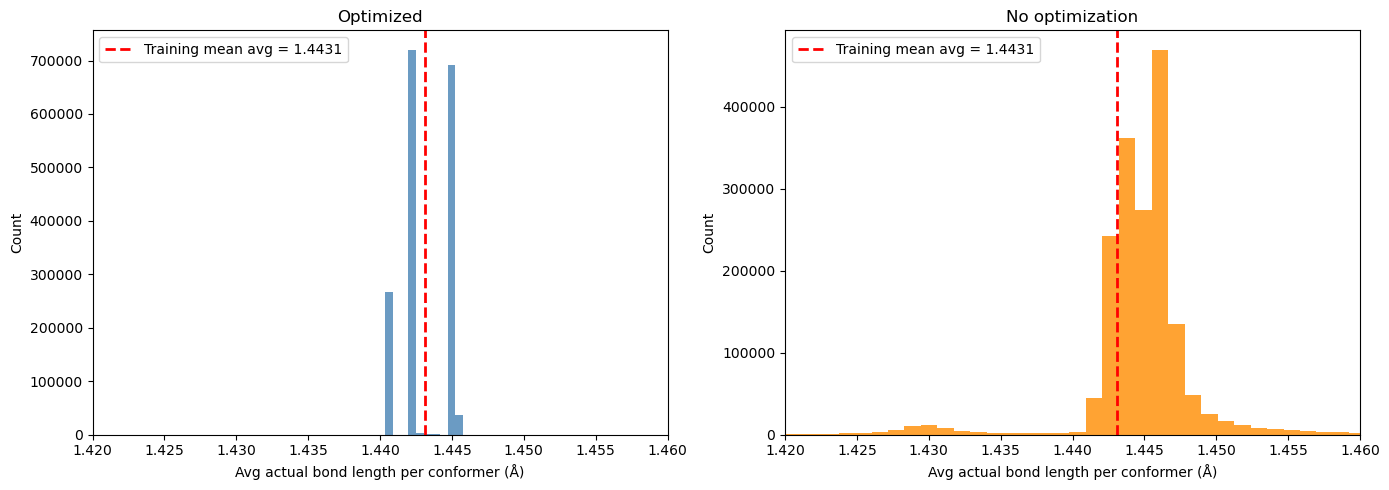

In [49]:
# Read summary data from CSVs instead of recomputing
summary_opt = pd.read_csv("sample/ring_bond_length_summary.csv")
summary_noopt = pd.read_csv("sample/ring_bond_length_summary_no_opt.csv")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
xmin = 1.42
xmax = 1.46

axes[0].hist(summary_opt["avg_actual_length"], bins=150, alpha=0.8, color="steelblue", edgecolor="none")
axes[0].axvline(overall_training_mean, color="red", linewidth=2, linestyle="--",
                label=f"Training mean avg = {overall_training_mean:.4f}")
axes[0].set_title("Optimized")
axes[0].set_xlabel("Avg actual bond length per conformer (Å)")
axes[0].set_ylabel("Count")
axes[0].set_xlim(xmin, xmax)
axes[0].legend()

axes[1].hist(summary_noopt["avg_actual_length"], bins=150, alpha=0.8, color="darkorange", edgecolor="none")
axes[1].axvline(overall_training_mean, color="red", linewidth=2, linestyle="--",
                label=f"Training mean avg = {overall_training_mean:.4f}")
axes[1].set_title("No optimization")
axes[1].set_xlabel("Avg actual bond length per conformer (Å)")
axes[1].set_ylabel("Count")
axes[1].set_xlim(xmin, xmax)
axes[1].legend()

plt.tight_layout()
plt.show()

In [46]:
summary_noopt["avg_actual_length"].min()

1.3755738